In [ ]:
!pip install torch==2.2.1 torchvision==0.17.1 torchaudio==2.2.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip uninstall numpy -y -q
!pip install "numpy<2.0.0" -q
!pip install lightning pytorch-forecasting -q

import os
os.kill(os.getpid(), 9)
try:
    import lightning as pl
    import pytorch_forecasting
    print(f'Python             : {sys.version[:6]}')
    print(f'PyTorch            : {torch.__version__}')
    print(f'Lightning          : {pl.__version__}')
    print(f'PyTorch Forecasting: {pytorch_forecasting.__version__}')
    print(f'GPU                : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')
except ImportError:
    print("\n Runtime Restart needed")

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26

In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet('train_preprocessed.parquet')
val_df   = pd.read_parquet('val_preprocessed.parquet')
test_df  = pd.read_parquet('test_preprocessed.parquet')

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    df['Date'] = pd.to_datetime(df['Date'])
    print(f'{name}: {df["Date"].min().date()} → {df["Date"].max().date()} | '
          f'{len(df):,} rows | '
          f'zero demand: {(df["Order_Demand"]==0).mean()*100:.1f}%')

print(f'\nProduct_Code: {train_df["Product_Code"].nunique()}')
print(f'Warehouse   : {train_df["Warehouse"].nunique()}')
print(f'Series pairs: {train_df.groupby(["Product_Code","Warehouse"]).ngroups}')
print(f'\nColumns: {train_df.columns.tolist()}')

Train: 2011-01-10 → 2015-06-01 | 240,414 rows | zero demand: 54.5%
Val: 2015-06-08 → 2016-03-21 | 57,744 rows | zero demand: 52.9%
Test: 2016-03-28 → 2017-01-09 | 53,998 rows | zero demand: 51.2%

Product_Code: 2113
Warehouse   : 4
Series pairs: 2792

Columns: ['Product_Code', 'Warehouse', 'Date', 'Order_Demand', 'Copper_Price_Lag1', 'Aluminum_Price_Lag1', 'Oil_Price_Lag1', 'USD_Index_Lag1', 'SP500_Lag1', 'Industrial_ETF_Lag1', 'Industrial_Production_Lag1', 'Capacity_Utilization_Lag1', 'Durable_Goods_Orders_Lag1', 'PPI_All_Commodities_Lag1', 'Crude_Oil_WTI_Lag1', 'Consumer_Sentiment_Lag1', 'Fed_Funds_Rate_Lag1', 'Treasury_10Y_Lag1', 'Copper_Aluminum_Ratio_Lag1', 'Copper_Price_Momentum4W_Lag1', 'Aluminum_Price_Momentum4W_Lag1', 'Oil_Price_Momentum4W_Lag1', 'Yield_Spread_Lag1', 'Week_Of_Year', 'Month', 'Quarter', 'Year', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Is_Quarter_End', 'Demand_Lag1W', 'Demand_Lag2W', 'Demand_Lag4W', 'Demand_Lag8W', 'Demand_Lag12W', 'Demand_Lag52W', 'De

In [2]:
import random, warnings
import torch
import numpy as np
import lightning as pl
warnings.filterwarnings('ignore')

torch.set_float32_matmul_precision('high')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

CFG = {
    'target'   : 'Order_Demand',
    'time_col' : 'Date',
    'group_col': 'Product_Code',
    'group_ids' : ['Product_Code', 'Warehouse'],

    'forecast_horizon'  : 1,
    'max_encoder_length': 52,
    'min_encoder_length': 4,

    'batch_size' : 128,
    'num_workers': 4,

    'static_categoricals': ['Product_Code', 'Warehouse', 'Demand_Cluster'],
    'static_reals'       : [],

    'time_varying_known_reals': [
        'Week_Of_Year', 'Month', 'Quarter', 'Year',
        'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Is_Quarter_End',

        'Copper_Price_Lag1', 'Aluminum_Price_Lag1', 'Oil_Price_Lag1',
        'USD_Index_Lag1', 'SP500_Lag1', 'Industrial_ETF_Lag1',
        'Industrial_Production_Lag1', 'Capacity_Utilization_Lag1',
        'Durable_Goods_Orders_Lag1', 'PPI_All_Commodities_Lag1',
        'Crude_Oil_WTI_Lag1', 'Consumer_Sentiment_Lag1',
        'Fed_Funds_Rate_Lag1', 'Treasury_10Y_Lag1',
        'Copper_Aluminum_Ratio_Lag1', 'Copper_Price_Momentum4W_Lag1',
        'Aluminum_Price_Momentum4W_Lag1', 'Oil_Price_Momentum4W_Lag1',
        'Yield_Spread_Lag1',
    ],
    'time_varying_known_categoricals': [],

    'time_varying_unknown_reals': [
        'Demand_Lag1W', 'Demand_Lag2W', 'Demand_Lag4W',
        'Demand_Lag8W', 'Demand_Lag12W', 'Demand_Lag52W',
        'Demand_RollMean4W', 'Demand_RollStd4W',
        'Demand_RollMean8W', 'Demand_RollStd8W',
        'Demand_RollMean12W', 'Demand_RollStd12W',
        'Demand_Trend', 'Demand_YoY_Growth', 'Demand_Expanding_Mean',
        'Is_Zero_Demand', 'Weeks_Since_Last_Order',
    ],
}

for key in ['time_varying_known_reals', 'time_varying_unknown_reals',
            'static_categoricals', 'time_varying_known_categoricals']:
    before = CFG[key]
    CFG[key] = [c for c in before if c in train_df.columns]
    dropped = set(before) - set(CFG[key])
    if dropped:
        print(f'[WARN] {key}: dropped {dropped}   <-- should be EMPTY now; if not, columns truly are missing from your parquet')

print('Config OK')
print(f'  known_reals   ({len(CFG["time_varying_known_reals"])}): {CFG["time_varying_known_reals"]}')
print(f'  unknown_reals ({len(CFG["time_varying_unknown_reals"])}): {CFG["time_varying_unknown_reals"]}')
print(f'  static_categoricals: {CFG["static_categoricals"]}')

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.1+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Config OK
  known_reals   (28): ['Week_Of_Year', 'Month', 'Quarter', 'Year', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'Is_Quarter_End', 'Copper_Price_Lag1', 'Aluminum_Price_Lag1', 'Oil_Price_Lag1', 'USD_Index_Lag1', 'SP500_Lag1', 'Industrial_ETF_Lag1', 'Industrial_Production_Lag1', 'Capacity_Utilization_Lag1', 'Durable_Goods_Orders_Lag1', 'PPI_All_Commodities_Lag1', 'Crude_Oil_WTI_Lag1', 'Consumer_Sentiment_Lag1', 'Fed_Funds_Rate_Lag1', 'Treasury_10Y_Lag1', 'Copper_Aluminum_Ratio_Lag1', 'Copper_Price_Momentum4W_Lag1', 'Aluminum_Price_Momentum4W_Lag1', 'Oil_Price_Momentum4W_Lag1', 'Yield_Spread_Lag1']
  unknown_reals (17): ['Demand_Lag1W', 'Demand_Lag2W', 'Demand_Lag4W', 'Demand_Lag8W', 'Demand_Lag12W', 'Demand_Lag52W', 'Demand_RollMean4W', 'Demand_RollStd4W', 'Demand_RollMean8W', 'Demand_RollStd8W', 'Demand_RollMean12W', 'Demand_RollStd12W', 'Demand_Trend', 'Demand_YoY_Growth', 'Demand_Expanding_Mean', 'Is_Zero_Demand', 'Weeks_Since_Last_Order']
  static_categoricals: ['Produc

In [3]:
# Fill missing weeks + time_idx
from pathlib import Path

def fill_missing_weeks(df: pd.DataFrame) -> pd.DataFrame:
    filled = []
    for (prod, wh), grp in df.groupby(['Product_Code', 'Warehouse']):
        cluster_val = grp['Demand_Cluster'].iloc[0] if 'Demand_Cluster' in grp.columns else None

        full_range = pd.date_range(
            start=grp['Date'].min(),
            end=grp['Date'].max(),
            freq='7D'
        )
        grp = (grp.set_index('Date')
                  .reindex(full_range)
                  .reset_index()
                  .rename(columns={'index': 'Date'}))
        grp['Product_Code'] = prod
        grp['Warehouse']    = wh
        if cluster_val is not None:
            grp['Demand_Cluster'] = cluster_val
        grp['Order_Demand'] = grp['Order_Demand'].fillna(0)
        num_cols = grp.select_dtypes(include='number').columns
        grp[num_cols] = grp[num_cols].fillna(0)
        filled.append(grp)
    return pd.concat(filled, ignore_index=True)


def add_time_index(df: pd.DataFrame) -> pd.DataFrame:
    #Global integer time index
    ts_map = {ts: i for i, ts in enumerate(sorted(df['Date'].unique()))}
    df['time_idx'] = df['Date'].map(ts_map)
    return df


train_df = fill_missing_weeks(train_df)
val_df   = fill_missing_weeks(val_df)
test_df  = fill_missing_weeks(test_df)

combined = pd.concat([train_df, val_df, test_df], ignore_index=True)
combined = add_time_index(combined)

train_end = train_df['Date'].max()
val_end   = val_df['Date'].max()
train_df  = combined[combined['Date'] <= train_end].copy()
val_df    = combined[(combined['Date'] > train_end) & (combined['Date'] <= val_end)].copy()
test_df   = combined[combined['Date'] > val_end].copy()

for df in [train_df, val_df, test_df]:
    for col in CFG['static_categoricals']:
        if col in df.columns:
            df[col] = df[col].astype(str)

print(f'Train: {len(train_df):,} rows | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'time_idx range: {combined["time_idx"].min()} → {combined["time_idx"].max()}')

Train: 463,189 rows | Val: 104,531 | Test: 97,364
time_idx range: 0 → 313


# PART A: FEATURE SELECTION (Pre-train) Correlation Filter on Time-Varying Reals

In [4]:
# FEATURE SELECTION (Pre-train): Correlation Filter
import json

CORR_THRESHOLD_TFT = 0.95

candidate_reals = list(dict.fromkeys(
    CFG['time_varying_known_reals'] + CFG['time_varying_unknown_reals']
))
candidate_reals = [c for c in candidate_reals if c in train_df.columns]

print('FEATURE SELECTION (TFT) — Correlation Filter')
print(f"\n  Candidate continuous features: {len(candidate_reals)}")

priority_features = set()
try:
    with open('selected_features.json') as f:
        lgbm_selection = json.load(f)
    priority_features = set(lgbm_selection.get('selected_features', []))
    print(f"  Loaded {len(priority_features)} priority features from LightGBM selected_features.json")
except FileNotFoundError:
    print("  selected_features.json (LightGBM) not found — skipping priority, "
          "using appearance order to decide which feature to keep.")

corr_matrix_tft = train_df[candidate_reals].corr().abs()
to_drop_tft = set()
cols_tft = corr_matrix_tft.columns.tolist()

for i in range(len(cols_tft)):
    for j in range(i + 1, len(cols_tft)):
        f1, f2 = cols_tft[i], cols_tft[j]
        if f1 in to_drop_tft or f2 in to_drop_tft:
            continue
        corr_val = corr_matrix_tft.iloc[i, j]
        if corr_val > CORR_THRESHOLD_TFT:
            if f1 in priority_features and f2 not in priority_features:
                weaker = f2
            elif f2 in priority_features and f1 not in priority_features:
                weaker = f1
            else:
                weaker = f2
            stronger = f1 if weaker == f2 else f2
            to_drop_tft.add(weaker)
            print(f"    Drop '{weaker}' (corr={corr_val:.3f} with '{stronger}')")

print(f"\n  Dropped {len(to_drop_tft)} features due to high correlation (threshold={CORR_THRESHOLD_TFT})")

CFG['time_varying_known_reals'] = [c for c in CFG['time_varying_known_reals'] if c not in to_drop_tft]
CFG['time_varying_unknown_reals'] = [c for c in CFG['time_varying_unknown_reals'] if c not in to_drop_tft]

print(f"\n  known_reals (after filter)   : {CFG['time_varying_known_reals']}")
print(f"  unknown_reals (after filter) : {CFG['time_varying_unknown_reals']}")

with open('tft_corr_filter_report.json', 'w') as f:
    json.dump({
        'candidate_reals': candidate_reals,
        'dropped_correlation': sorted(to_drop_tft),
        'known_reals_final': CFG['time_varying_known_reals'],
        'unknown_reals_final': CFG['time_varying_unknown_reals'],
    }, f, indent=2, ensure_ascii=False)

FEATURE SELECTION (TFT) — Correlation Filter

  Candidate continuous features: 45
  selected_features.json (LightGBM) not found — skipping priority, using appearance order to decide which feature to keep.
    Drop 'Month' (corr=0.970 with 'Week_Of_Year')
    Drop 'Quarter' (corr=0.961 with 'Week_Of_Year')
    Drop 'Copper_Price_Lag1' (corr=0.990 with 'Year')
    Drop 'Aluminum_Price_Lag1' (corr=0.998 with 'Year')
    Drop 'Oil_Price_Lag1' (corr=0.964 with 'Year')
    Drop 'USD_Index_Lag1' (corr=0.996 with 'Year')
    Drop 'SP500_Lag1' (corr=0.976 with 'Year')
    Drop 'Industrial_ETF_Lag1' (corr=0.965 with 'Year')
    Drop 'Industrial_Production_Lag1' (corr=1.000 with 'Year')
    Drop 'Capacity_Utilization_Lag1' (corr=1.000 with 'Year')
    Drop 'Durable_Goods_Orders_Lag1' (corr=0.996 with 'Year')
    Drop 'PPI_All_Commodities_Lag1' (corr=0.999 with 'Year')
    Drop 'Crude_Oil_WTI_Lag1' (corr=0.964 with 'Year')
    Drop 'Consumer_Sentiment_Lag1' (corr=0.993 with 'Year')
    Drop 'Treas

In [5]:
import warnings
warnings.filterwarnings('ignore')

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, EncoderNormalizer
MAX_ENC  = CFG['max_encoder_length']
MIN_ENC  = CFG['min_encoder_length']
MAX_PRED = CFG['forecast_horizon']

min_rows = MIN_ENC + MAX_PRED
counts   = train_df.groupby(CFG['group_ids'])['time_idx'].count()
valid_pairs = counts[counts >= min_rows].index          # MultiIndex (prod, wh)
print(f'Series long enough: {len(valid_pairs)} group with (Product×Warehouse)')
train_df_filtered = train_df.set_index(CFG['group_ids']).loc[
    train_df.set_index(CFG['group_ids']).index.isin(valid_pairs)
].reset_index()

known_pairs = set(map(tuple, train_df_filtered[CFG['group_ids']].drop_duplicates().values))
def filter_by_pairs(df):
    mask = df.apply(lambda r: (r['Product_Code'], r['Warehouse']) in known_pairs, axis=1)
    return df[mask]
val_df  = filter_by_pairs(val_df)
test_df = filter_by_pairs(test_df)

training_dataset = TimeSeriesDataSet(
    data=train_df_filtered,
    time_idx='time_idx',
    target=CFG['target'],
    group_ids=CFG['group_ids'],

    max_encoder_length=MAX_ENC,
    min_encoder_length=MIN_ENC,
    max_prediction_length=MAX_PRED,
    min_prediction_length=MAX_PRED,

    static_categoricals=CFG['static_categoricals'],
    static_reals=CFG['static_reals'],
    time_varying_known_reals=CFG['time_varying_known_reals'],
    time_varying_known_categoricals=CFG['time_varying_known_categoricals'],
    time_varying_unknown_reals=(
        [CFG['target']] + CFG['time_varying_unknown_reals']
    ),

    target_normalizer=EncoderNormalizer(transformation='softplus'),
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    predict_mode=False
)

val_dataset  = TimeSeriesDataSet.from_dataset(training_dataset, val_df,  predict=False, stop_randomization=True)
test_dataset = TimeSeriesDataSet.from_dataset(training_dataset, test_df, predict=False, stop_randomization=True)

train_loader = training_dataset.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=2,
    persistent_workers=True, pin_memory=True,
)
val_loader = val_dataset.to_dataloader(
    train=False, batch_size=CFG['batch_size'], num_workers=2,
    persistent_workers=True, pin_memory=True,
)
test_loader = test_dataset.to_dataloader(
    train=False, batch_size=CFG['batch_size'], num_workers=2,
    persistent_workers=True, pin_memory=True,
)

print(f'Train samples: {len(training_dataset):,}')
print(f'Val samples  : {len(val_dataset):,}')
print(f'Test samples : {len(test_dataset):,}')

Series long enough: 2773 group with (Product×Warehouse)
Train samples: 584,330
Val samples  : 182,763
Test samples : 167,474


In [6]:
nan_counts = train_df_filtered.isnull().sum()
nan_cols = nan_counts[nan_counts > 0]
if not nan_cols.empty:
    print(f'  Colums with many NaN:\n{nan_cols}')
else:
    print(' Cannot find NaN.')

numeric_cols = train_df_filtered.select_dtypes(include=np.number).columns
inf_found = False
for col in numeric_cols:
    if (np.isinf(train_df_filtered[col])).any():
        print(f'  Column \'{col}\' has Inf.')
        inf_found = True
if not inf_found:
    print(' Cannot find Inf.')

negative_value_found = False
for col in ['Order_Demand', 'Copper_Price_Lag1', 'Aluminum_Price_Lag1', 'Oil_Price_Lag1', 'USD_Index_Lag1', 'SP500_Lag1']:
    if col in train_df_filtered.columns:
        neg_count = (train_df_filtered[col] < 0).sum()
        if neg_count > 0:
            print(f"Colmun '{col}' has {neg_count} negative values.")
            negative_value_found = True
if not negative_value_found:
    print(' Cannot find any negative value.')

display(train_df_filtered[numeric_cols].describe())


 Cannot find NaN.
 Cannot find Inf.
 Cannot find any negative value.


,Order_Demand,Copper_Price_Lag1,Aluminum_Price_Lag1,Oil_Price_Lag1,USD_Index_Lag1,SP500_Lag1,Industrial_ETF_Lag1,Industrial_Production_Lag1,Capacity_Utilization_Lag1,Durable_Goods_Orders_Lag1,...,Demand_Trend,Demand_YoY_Growth,Demand_Expanding_Mean,Is_Zero_Demand,Weeks_Since_Last_Order,Has_52W_History,Has_YoY_Data,Product_Code_TE,Warehouse_TE,time_idx
count,4.631600e+05,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,...,463160.000000,4.631600e+05,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000,463160.000000
mean,8.841567e+02,1.697716,1137.228971,46.576394,43.232129,887.929258,19.220708,51.716070,40.297573,119105.687753,...,0.238115,2.046826e+02,838.895165,0.282984,4.368452,0.247495,0.243244,900.059257,883.874659,142.032034
std,1.424821e+04,1.650328,1096.619417,46.482166,41.783636,875.679368,19.169115,49.790818,38.797285,115111.167329,...,4330.855484,7.254517e+03,8101.216445,0.450449,16.965573,0.431557,0.429042,4820.095675,1531.966459,50.354650
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-493333.333333,-9.999993e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.000000
50%,0.000000e+00,2.637000,2024.535714,48.074286,79.202857,1314.504307,27.025018,98.006900,76.622700,216864.000000,...,0.000000,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,95.422703,309.405546,143.000000
75%,0.000000e+00,3.273357,2172.750000,95.369999,81.304286,1756.362863,38.739222,99.644000,77.352714,226783.000000,...,0.000000,0.000000e+00,49.435626,1.000000,2.000000,0.000000,0.000000,365.732489,852.650827,186.000000
max,2.500000e+06,4.394214,2465.857143,109.321429,99.737144,2126.962926,47.299015,101.593000,79.296200,300114.000000,...,315000.000000,1.200000e+06,606363.636364,1.000000,180.000000,1.000000,1.000000,119317.208910,5655.492266,229.000000


In [7]:
import torch
import numpy as np

for idx, batch in enumerate(train_loader):
    x, y = batch
    found_issue = False
    for key, val in x.items():
        if isinstance(val, torch.Tensor) and (torch.isnan(val).any() or torch.isinf(val).any()):
            print(f"  NaN or Inf found in input tensor '{key}' in batch {idx+1} from train_loader!")
            found_issue = True
    if isinstance(y, tuple) and len(y) > 0 and isinstance(y[0], torch.Tensor) and (torch.isnan(y[0]).any() or torch.isinf(y[0]).any()):
        print(f"  NaN or Inf found in target tensor 'y' in batch {idx+1} from train_loader!")
        found_issue = True

    if not found_issue:
        print(f"  Batch {idx+1} (train_loader): No NaN/Inf found. (Checked 1 batch)")
    break

  Batch 1 (train_loader): No NaN/Inf found. (Checked 1 batch)


In [8]:
import torch

print("\nChecking for negative values in Order_Demand in a sample training batch from train_loader...")
for idx, batch in enumerate(train_loader):
    _, y = batch

    if isinstance(y, tuple) and len(y) > 0 and isinstance(y[0], torch.Tensor):
        negative_values = y[0][y[0] < 0]
        if negative_values.numel() > 0:
            print(f"  Negative Order_Demand values found in batch {idx+1} from train_loader!")
            print(f"  First 10 negative values: {negative_values[:10].tolist()}")
        else:
            print(f"  Batch {idx+1} (train_loader): No negative Order_Demand values found. (Checked 1 batch)")
    else:
        print(f"Could not verify Order_Demand in batch {idx+1}. Target 'y' not in expected format.")
    break


Checking for negative values in Order_Demand in a sample training batch from train_loader...
Could not verify Order_Demand in batch 1. Target 'y' not in expected format.


In [9]:
print("DATASET DIAGNOSTICS")
print(f"batch_size       : {CFG['batch_size']}")
print(f"num_workers      : {CFG['num_workers']}")
print(f"Train samples    : {len(training_dataset):,}")
print(f"Batches/epoch    : {len(train_loader):,}")
print(f"Val samples      : {len(val_dataset):,}")
print(f"Val batches      : {len(val_loader):,}")

print(f"\nProduct×Warehouse pairs (train): {train_df_filtered.groupby(['Product_Code','Warehouse']).ngroups:,}")
print(f"max_encoder_length : {CFG['max_encoder_length']}")
print(f"forecast_horizon   : {CFG['forecast_horizon']}")

batch = next(iter(train_loader))
x, y = batch
print(f"\nSample batch:")
print(f"  encoder_cont shape : {x['encoder_cont'].shape}")
print(f"  target shape       : {y[0].shape}")

DATASET DIAGNOSTICS
batch_size       : 128
num_workers      : 4
Train samples    : 584,330
Batches/epoch    : 4,565
Val samples      : 182,763
Val batches      : 1,428

Product×Warehouse pairs (train): 2,773
max_encoder_length : 52
forecast_horizon   : 1

Sample batch:
  encoder_cont shape : torch.Size([128, 52, 30])
  target shape       : torch.Size([128, 1])


In [10]:
import warnings
warnings.filterwarnings('ignore')

#Build + Train TFT
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss # Import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor

from pathlib import Path
Path('checkpoints').mkdir(exist_ok=True)

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=3e-4,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=32,
    loss=QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]), # Changed to QuantileLoss
    log_interval=10,
    reduce_on_plateau_patience=6,
)
n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f'TFT parameters: {n_params:,}')

for name, param in tft.named_parameters():
    if torch.isnan(param).any() or torch.isinf(param).any():
        raise ValueError(f"NaN or Inf found in model parameter: {name}")
for name, buf in tft.named_buffers():
    if torch.isnan(buf).any() or torch.isinf(buf).any():
        raise ValueError(f"NaN or Inf found in model buffer: {name}")
print("Model parameters and buffers are clean (no NaN/Inf).")

for idx, batch in enumerate(train_loader):
    x, y = batch
    for key, val in x.items():
        if isinstance(val, torch.Tensor) and (torch.isnan(val).any() or torch.isinf(val).any()):
            raise ValueError(f"NaN or Inf found in input tensor '{key}' from train_loader before training!")

    if torch.isnan(y[0]).any() or torch.isinf(y[0]).any():
        raise ValueError("NaN or Inf found in target tensor 'y' from train_loader before training!")
    print(f"Batch {idx+1} (train_loader): No NaN/Inf found.")
    break # Only check the first batch

for idx, batch in enumerate(val_loader):
    x, y = batch
    for key, val in x.items():
        if isinstance(val, torch.Tensor) and (torch.isnan(val).any() or torch.isinf(val).any()):
            raise ValueError(f"NaN or Inf found in input tensor '{key}' from val_loader before training!")
    if torch.isnan(y[0]).any() or torch.isinf(y[0]).any():
        raise ValueError("NaN or Inf found in target tensor 'y' from val_loader before training!")
    print(f"Batch {idx+1} (val_loader): No NaN/Inf found.")

TFT parameters: 643,137
Model parameters and buffers are clean (no NaN/Inf).
Batch 1 (train_loader): No NaN/Inf found.
Batch 1 (val_loader): No NaN/Inf found.
Batch 2 (val_loader): No NaN/Inf found.
Batch 3 (val_loader): No NaN/Inf found.
Batch 4 (val_loader): No NaN/Inf found.
Batch 5 (val_loader): No NaN/Inf found.
Batch 6 (val_loader): No NaN/Inf found.
Batch 7 (val_loader): No NaN/Inf found.
Batch 8 (val_loader): No NaN/Inf found.
Batch 9 (val_loader): No NaN/Inf found.
Batch 10 (val_loader): No NaN/Inf found.
Batch 11 (val_loader): No NaN/Inf found.
Batch 12 (val_loader): No NaN/Inf found.
Batch 13 (val_loader): No NaN/Inf found.
Batch 14 (val_loader): No NaN/Inf found.
Batch 15 (val_loader): No NaN/Inf found.
Batch 16 (val_loader): No NaN/Inf found.
Batch 17 (val_loader): No NaN/Inf found.
Batch 18 (val_loader): No NaN/Inf found.
Batch 19 (val_loader): No NaN/Inf found.
Batch 20 (val_loader): No NaN/Inf found.
Batch 21 (val_loader): No NaN/Inf found.
Batch 22 (val_loader): No NaN

In [11]:
import warnings
warnings.filterwarnings('ignore')
import torch
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
import lightning as pl
from pathlib import Path

Path('checkpoints').mkdir(exist_ok=True)

tft = TemporalFusionTransformer.from_dataset(
        training_dataset,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.15,
        hidden_continuous_size=16,
        loss=QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
        log_interval=10,
        reduce_on_plateau_patience=4,
    )

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    precision='32',
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        ModelCheckpoint(dirpath='checkpoints', filename='tft_best', monitor='val_loss', save_top_k=1),
        LearningRateMonitor(logging_interval='epoch'),
    ],
    enable_model_summary=True,
)
torch.cuda.empty_cache()
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 67.1 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    960 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 64.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 20.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    165 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 210 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 210 K                                                                                                
Total estimated model params size (MB): 0.844                                                                      
Modules in train mode: 765                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [14]:
import warnings
warnings.filterwarnings('ignore')

# Evaluate
ZERO_THR = 1e-6

def compute_metrics(y_true, y_pred, label=''):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse  = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    mae   = float(np.mean(np.abs(y_true - y_pred)))
    denom = np.sum(np.abs(y_true))
    wmape = float(np.sum(np.abs(y_true - y_pred)) / denom) if denom > ZERO_THR else float('nan')
    mask  = np.abs(y_true) > ZERO_THR
    mape  = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))) if mask.any() else float('nan')
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2    = float(1 - ss_res/ss_tot) if ss_tot > ZERO_THR else float('nan')
    n_zero = int((~mask).sum())
    print(f'[{label}] RMSE={rmse:.4f}  MAE={mae:.4f}  '
          f'WMAPE={wmape:.4f}  MAPE={mape:.4f}  R²={r2:.4f}  '
          f'(MAPE excludes {n_zero} zero rows)')
    return {'RMSE': rmse, 'MAE': mae, 'WMAPE': wmape, 'MAPE': mape, 'R2': r2}

# Load best model
best_ckpt = trainer.checkpoint_callback.best_model_path
best_tft  = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
best_tft.eval()

# Predictions
def get_preds(model, loader):
    model.eval()
    y_pred_list, y_true_list, mid_list = [], [], []

    device = next(model.parameters()).device

    with torch.no_grad():
        for batch in loader:
            x, (y, weight) = batch
            for key, value in x.items():
                if isinstance(value, torch.Tensor):
                    x[key] = value.to(device)

            out = model(x)
            preds = out["prediction"].cpu().numpy()


            if preds.ndim == 3:
                mid_idx = preds.shape[2] // 2
                preds = preds[:, :, mid_idx]

            y_true_list.append(y.cpu().numpy())
            y_pred_list.append(preds)

            groups = x["groups"].cpu().numpy().reshape(-1)
            mid_list.append(np.repeat(groups, CFG['forecast_horizon']))

    y_true = np.concatenate(y_true_list).reshape(-1)
    y_pred = np.concatenate(y_pred_list).reshape(-1)
    mids   = np.concatenate(mid_list)

    return y_true, y_pred, mids

y_true_val,  y_pred_val,  mids_val  = get_preds(best_tft, val_loader)
y_true_test, y_pred_test, mids_test = get_preds(best_tft, test_loader)

val_metrics  = compute_metrics(y_true_val,  y_pred_val,  label='TFT Val')
test_metrics = compute_metrics(y_true_test, y_pred_test, label='TFT Test')

[TFT Val] RMSE=34503.1367  MAE=2240.5942  WMAPE=0.9733  MAPE=1.4475  R²=0.0248  (MAPE excludes 105212 zero rows)
[TFT Test] RMSE=18184.7637  MAE=1652.0079  WMAPE=0.9629  MAPE=1.3324  R²=0.0587  (MAPE excludes 92269 zero rows)


In [15]:
#Comparison table
lgbm_metrics = {
    'RMSE' : 20043.25,
    'MAE'  : 1518.60,
    'WMAPE': 72.60,

}

comparison = pd.DataFrame([
    {'Model': 'TFT (Global)',  **test_metrics},
    {'Model': 'LightGBM Best', **lgbm_metrics},
])[['Model', 'RMSE', 'MAE', 'WMAPE', 'R2']]


print('MODEL COMPARISON')
print(comparison.to_string(index=False))

MODEL COMPARISON
        Model         RMSE         MAE     WMAPE       R2
 TFT (Global) 18184.763672 1652.007935  0.962878 0.058665
LightGBM Best 20043.250000 1518.600000 72.600000      NaN


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

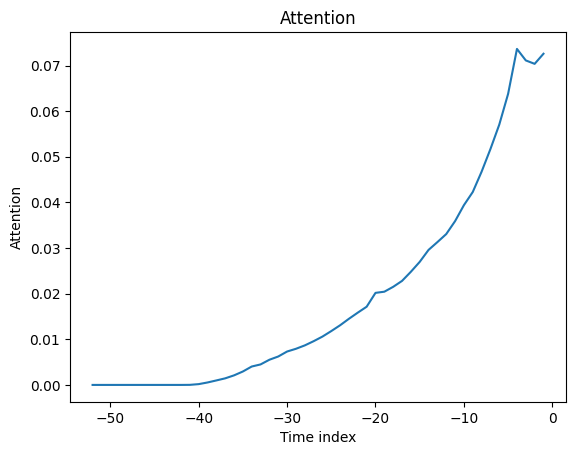

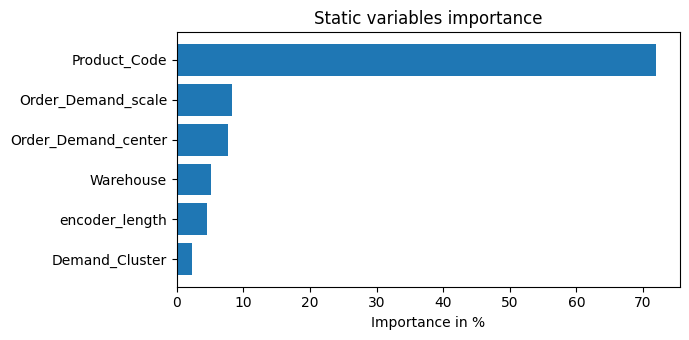

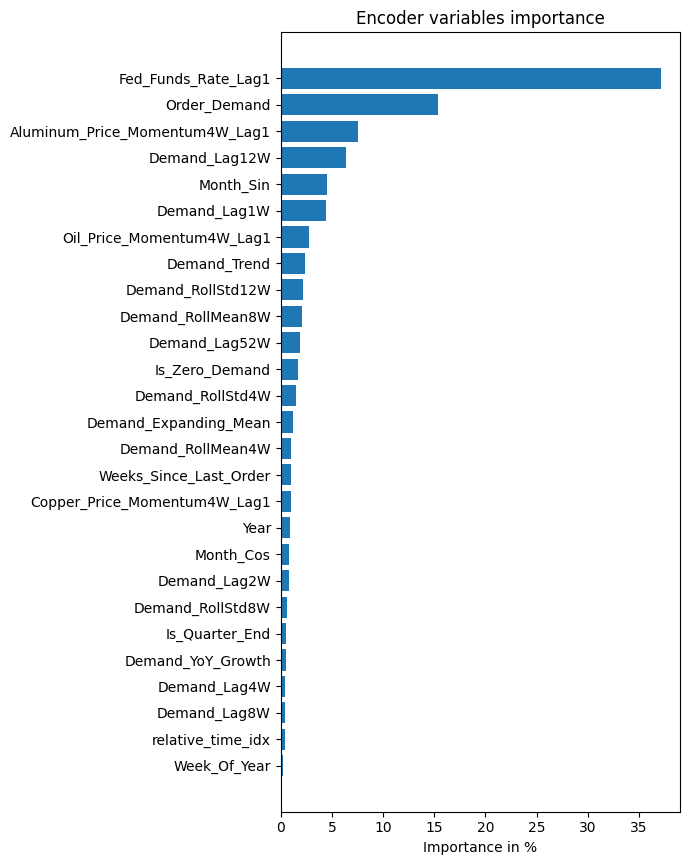

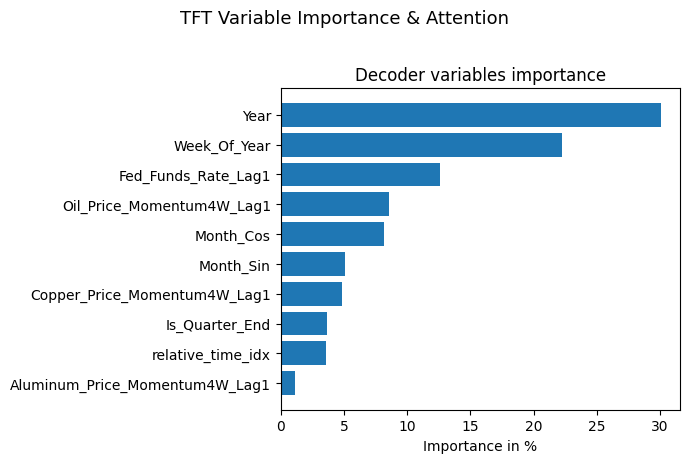

In [16]:
# Interpretation
import matplotlib.pyplot as plt

raw_preds    = best_tft.predict(test_loader, mode='raw', return_x=True, return_index=True)
interpretation = best_tft.interpret_output(raw_preds.output, reduction='sum')
fig = best_tft.plot_interpretation(interpretation)
plt.suptitle('TFT Variable Importance & Attention', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('tft_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()

# PART B: FEATURE SELECTION (Post-train) Importance Threshold (TFT Variable Selection) Retrain & Compare WMAPE

In [17]:
# FEATURE SELECTION (Post-train): Importance Threshold + Retrain
import json

IMPORTANCE_PCT_THRESHOLD_TFT = 0.01  # drop features with importance < 1% of max importance

print('FEATURE SELECTION (TFT) — Importance Threshold (from TFT Variable Selection Network)')

weak_tft = []
try:
    enc_vars = best_tft.encoder_variables
    dec_vars = best_tft.decoder_variables
    enc_importance = interpretation['encoder_variables'].cpu().numpy()
    dec_importance = interpretation['decoder_variables'].cpu().numpy()

    imp_df = pd.concat([
        pd.DataFrame({'feature': enc_vars, 'importance': enc_importance, 'side': 'encoder'}),
        pd.DataFrame({'feature': dec_vars, 'importance': dec_importance, 'side': 'decoder'}),
    ], ignore_index=True)

    combined_imp = imp_df.groupby('feature')['importance'].max().sort_values(ascending=False)

    print('\n  Variable importance (TFT Variable Selection Network):')
    for feat, val in combined_imp.items():
        print(f"    {feat:<30s} {val:.4f}")

    imp_threshold_tft = combined_imp.max() * IMPORTANCE_PCT_THRESHOLD_TFT
    weak_tft = [
        f for f in combined_imp.index
        if combined_imp[f] < imp_threshold_tft
        and f not in CFG['static_categoricals']
        and f != CFG['target']
    ]
    print(f"\n  Threshold: {imp_threshold_tft:.4f}  (1% of max importance)")
    print(f"  Weak features (will be dropped): {weak_tft}")

except (AttributeError, KeyError) as e:
    print(f"  Could not retrieve importance from TFT (attribute name might differ based on pytorch-forecasting version): {e}")
    print(" Skipping importance threshold step, retaining feature set after correlation filter.")

CFG_SELECTED = {**CFG}
CFG_SELECTED['time_varying_known_reals'] = [c for c in CFG['time_varying_known_reals'] if c not in weak_tft]
CFG_SELECTED['time_varying_unknown_reals'] = [c for c in CFG['time_varying_unknown_reals'] if c not in weak_tft]

n_before = len(CFG['time_varying_known_reals']) + len(CFG['time_varying_unknown_reals'])
n_after  = len(CFG_SELECTED['time_varying_known_reals']) + len(CFG_SELECTED['time_varying_unknown_reals'])
print(f"\n  Total features: {n_before} -> {n_after} (dropped {n_before - n_after})")

if n_after < n_before:
    print('RETRAIN — TFT with Selected Features')

    training_dataset_sel = TimeSeriesDataSet(
        data=train_df_filtered,
        time_idx='time_idx',
        target=CFG_SELECTED['target'],
        group_ids=CFG_SELECTED['group_ids'],
        max_encoder_length=MAX_ENC,
        min_encoder_length=MIN_ENC,
        max_prediction_length=MAX_PRED,
        min_prediction_length=MAX_PRED,
        static_categoricals=CFG_SELECTED['static_categoricals'],
        static_reals=CFG_SELECTED['static_reals'],
        time_varying_known_reals=CFG_SELECTED['time_varying_known_reals'],
        time_varying_known_categoricals=CFG_SELECTED['time_varying_known_categoricals'],
        time_varying_unknown_reals=(
            [CFG_SELECTED['target']] + CFG_SELECTED['time_varying_unknown_reals']
        ),
        target_normalizer=EncoderNormalizer(transformation='softplus'),
        allow_missing_timesteps=True,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        predict_mode=False,
    )
    val_dataset_sel  = TimeSeriesDataSet.from_dataset(training_dataset_sel, val_df,  predict=False, stop_randomization=True)
    test_dataset_sel = TimeSeriesDataSet.from_dataset(training_dataset_sel, test_df, predict=False, stop_randomization=True)

    train_loader_sel = training_dataset_sel.to_dataloader(train=True,  batch_size=CFG['batch_size'], num_workers=CFG['num_workers'])
    val_loader_sel   = val_dataset_sel.to_dataloader(     train=False, batch_size=CFG['batch_size'], num_workers=CFG['num_workers'])
    test_loader_sel  = test_dataset_sel.to_dataloader(    train=False, batch_size=CFG['batch_size'], num_workers=CFG['num_workers'])

    Path('checkpoints').mkdir(exist_ok=True)

    tft_selected = TemporalFusionTransformer.from_dataset(
        training_dataset_sel,
        learning_rate=1e-3,
        hidden_size=32,
        attention_head_size=4,
        dropout=0.15,
        hidden_continuous_size=16,
        loss=QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
        log_interval=10,
        reduce_on_plateau_patience=4,
    )

    trainer_sel = pl.Trainer(
        max_epochs=50,
        accelerator='gpu',
        devices=1,
        gradient_clip_val=0.1,
        precision='32',
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, mode='min'),
            ModelCheckpoint(dirpath='checkpoints', filename='tft_selected_best', monitor='val_loss', save_top_k=1),
            LearningRateMonitor(logging_interval='epoch'),
        ],
        enable_model_summary=True,
    )

    torch.cuda.empty_cache()
    trainer_sel.fit(tft_selected, train_dataloaders=train_loader_sel, val_dataloaders=val_loader_sel)

    best_ckpt_sel = trainer_sel.checkpoint_callback.best_model_path
    best_tft_sel  = TemporalFusionTransformer.load_from_checkpoint(best_ckpt_sel)
    best_tft_sel.eval()

    y_true_test_sel, y_pred_test_sel, _ = get_preds(best_tft_sel, test_loader_sel)
    test_metrics_sel = compute_metrics(y_true_test_sel, y_pred_test_sel, label='TFT Selected Test')

    print(f"\n  {'Model':<30s} {'#Features':>10} {'RMSE':>10} {'MAE':>10} {'WMAPE':>10}")
    print(f"  {'TFT (Full features)':<30s} {n_before:>10} "
          f"{test_metrics['RMSE']:>10.4f} {test_metrics['MAE']:>10.4f} {test_metrics['WMAPE']:>9.4f}")
    print(f"  {'TFT (Selected features)':<30s} {n_after:>10} "
          f"{test_metrics_sel['RMSE']:>10.4f} {test_metrics_sel['MAE']:>10.4f} {test_metrics_sel['WMAPE']:>9.4f}")

    delta_wmape_tft = test_metrics_sel['WMAPE'] - test_metrics['WMAPE']
    print(f"\n  Delta WMAPE (Selected - Full): {delta_wmape_tft:+.4f}")
    if delta_wmape_tft <= 0.005:
        verdict_tft = 'OK — Feature selection retains/improves performance with fewer features -> RECOMMENDED.'
    elif delta_wmape_tft <= 0.02:
        verdict_tft = 'WARN — WMAPE increased slightly, consider retaining some important features that were removed.'
    else:
        verdict_tft = 'FAIL — WMAPE increased significantly, increase IMPORTANCE_PCT_THRESHOLD_TFT and re-run.'
    print(f"  Verdict: {verdict_tft}")
else:
    print('\n  No features removed by importance threshold — retaining the Full model (after correlation filter).')
    best_tft_sel = best_tft
    training_dataset_sel = training_dataset
    test_metrics_sel = test_metrics
    CFG_SELECTED = CFG

with open('tft_feature_selection_report.json', 'w') as f:
    json.dump({
        'known_reals_full': CFG['time_varying_known_reals'],
        'unknown_reals_full': CFG['time_varying_unknown_reals'],
        'dropped_low_importance': weak_tft,
        'known_reals_selected': CFG_SELECTED['time_varying_known_reals'],
        'unknown_reals_selected': CFG_SELECTED['time_varying_unknown_reals'],
        'wmape_full': test_metrics['WMAPE'],
        'wmape_selected': test_metrics_sel['WMAPE'],
    }, f, indent=2, ensure_ascii=False)


FEATURE SELECTION (TFT) — Importance Threshold (from TFT Variable Selection Network)

  Variable importance (TFT Variable Selection Network):
    Fed_Funds_Rate_Lag1            62239.9023
    Year                           50375.7539
    Week_Of_Year                   37315.9297
    Order_Demand                   25821.5840
    Oil_Price_Momentum4W_Lag1      14293.6445
    Month_Cos                      13706.5391
    Aluminum_Price_Momentum4W_Lag1 12709.5117
    Demand_Lag12W                  10645.8457
    Month_Sin                      8508.9805
    Copper_Price_Momentum4W_Lag1   8177.2368
    Demand_Lag1W                   7483.4961
    Is_Quarter_End                 6107.3335
    relative_time_idx              5994.4341
    Demand_Trend                   3953.9426
    Demand_RollStd12W              3619.9351
    Demand_RollMean8W              3463.6436
    Demand_Lag52W                  3230.0493
    Is_Zero_Demand                 2909.3530
    Demand_RollStd4W               2480.

In [18]:
Path('results').mkdir(exist_ok=True)

mids_test = raw_preds.index['Product_Code'].astype(str) + '_' + raw_preds.index['Warehouse'].astype(str)

pd.DataFrame({
    'material_id': mids_test,
    'y_true'     : y_true_test,
    'y_pred_tft' : y_pred_test,
}).to_csv('results/test_predictions.csv', index=False)

comparison.to_csv('results/comparison_metrics.csv', index=False)

from google.colab import files
files.download('results/test_predictions.csv')
files.download('results/comparison_metrics.csv')
files.download('tft_interpretation.png')
files.download('checkpoints/tft_best.ckpt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PART C: EXPORT ARTIFACTS TO BACKEND (pickle dataset params + config + checkpoint)

In [19]:
# EXPORT ARTIFACTS TO BACKEND
import pickle
import json
import shutil
from pathlib import Path

Path('results').mkdir(exist_ok=True)

FINAL_MODEL   = best_tft_sel if 'best_tft_sel' in globals() else best_tft
FINAL_DATASET = training_dataset_sel if 'training_dataset_sel' in globals() else training_dataset
FINAL_CFG     = CFG_SELECTED if 'CFG_SELECTED' in globals() else CFG

dataset_params = FINAL_DATASET.get_parameters()
with open('results/tft_dataset_params.pkl', 'wb') as f:
    pickle.dump(dataset_params, f)
print('Saved: results/tft_dataset_params.pkl')

with open('results/tft_config.json', 'w') as f:
    json.dump(FINAL_CFG, f, indent=2, ensure_ascii=False)
print('Saved: results/tft_config.json')

for fname in ['tft_corr_filter_report.json', 'tft_feature_selection_report.json']:
    src = Path(fname)
    if src.exists():
        shutil.copy(src, f'results/{fname}')
        print(f'Copied: results/{fname}')

final_ckpt_path = (
    trainer_sel.checkpoint_callback.best_model_path
    if 'trainer_sel' in globals() and 'best_tft_sel' in globals() and best_tft_sel is not best_tft
    else trainer.checkpoint_callback.best_model_path
)
shutil.copy(final_ckpt_path, 'results/tft_final.ckpt')
print(f'Saved: results/tft_final.ckpt  (copied from {final_ckpt_path})')

backend_snippet_lines = [
    'import pickle, json',
    'import pandas as pd',
    'from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer',
    '',
    'with open("tft_dataset_params.pkl", "rb") as f:',
    '    dataset_params = pickle.load(f)',
    'with open("tft_config.json") as f:',
    '    cfg = json.load(f)',
    '',
    'new_df = pd.read_parquet("...")            # new data, same schema as during training',
    'new_dataset = TimeSeriesDataSet.from_parameters(dataset_params, new_df, predict=True, stop_randomization=True)',
    'new_loader  = new_dataset.to_dataloader(train=False, batch_size=128)',
    '',
    'model = TemporalFusionTransformer.load_from_checkpoint("tft_final.ckpt")',
    'model.eval()',
    'preds = model.predict(new_loader, mode="prediction"),'
]
print('\n'.join(backend_snippet_lines))

from google.colab import files
for fname in ['tft_dataset_params.pkl', 'tft_config.json', 'tft_final.ckpt']:
    files.download(f'results/{fname}')

Saved: results/tft_dataset_params.pkl
Saved: results/tft_config.json
Copied: results/tft_corr_filter_report.json
Copied: results/tft_feature_selection_report.json
Saved: results/tft_final.ckpt  (copied from /content/checkpoints/tft_best.ckpt)
import pickle, json
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

with open("tft_dataset_params.pkl", "rb") as f:
    dataset_params = pickle.load(f)
with open("tft_config.json") as f:
    cfg = json.load(f)

new_df = pd.read_parquet("...")            # new data, same schema as during training
new_dataset = TimeSeriesDataSet.from_parameters(dataset_params, new_df, predict=True, stop_randomization=True)
new_loader  = new_dataset.to_dataloader(train=False, batch_size=128)

model = TemporalFusionTransformer.load_from_checkpoint("tft_final.ckpt")
model.eval()
preds = model.predict(new_loader, mode="prediction"),


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>